<a href="https://colab.research.google.com/github/SiivaDinh/AIFinal/blob/main/finalProjectAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is the start of my final project, it is a simple machine-learning project that attempts to predict a phenotype of a given yeast sample given its features (frequented regions/ conserved genetic regions) at different levels of kappa (strictness of deviation allowed from a frequented region) while using three ML techniques (random forest, SVR, and DNN).

In [1]:
import joblib
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import numpy as np

In [6]:
fr_ka0_path = "/content/FR_KA0.csv"
fr_ka1_path = "/content/FR_KA1.csv"
fr_ka2_path = "/content/FR_KA2.csv"

training_indices_path = "/content/yeast1000_training.txt"
testing_indices_path = "/content/yeast1000_testing.txt"
validation_indices_path = "/content/yeast1000_validation.txt"

df = pd.read_csv(fr_ka0_path)
phenotype_names = df.columns[-35:]
print(phenotype_names)

Index(['YPACETATE', 'YPDCAFEIN40', 'YPDHU', 'YPETHANOL', 'YPD14',
       'YPDCAFEIN50', 'YPDKCL2M', 'YPGALACTOSE', 'YPD40', 'YPDCHX05',
       'YPDLICL250MM', 'YPGLYCEROL', 'YPD42', 'YPDCHX1', 'YPDMV', 'YPRIBOSE',
       'YPD6AU', 'YPDCUSO410MM', 'YPDNACL15M', 'YPSORBITOL', 'YPDANISO10',
       'YPDDMSO', 'YPDNACL1M', 'YPXYLOSE', 'YPDANISO20', 'YPDETOH',
       'YPDNYSTATIN', 'YPDANISO50', 'YPDFLUCONAZOLE', 'YPDSDS',
       'YPDBENOMYL200', 'YPDFORMAMIDE4', 'YPDSODIUMMETAARSENITE',
       'YPDBENOMYL500', 'YPDFORMAMIDE5'],
      dtype='object')


In [9]:
def train_model(csv_file_path, training_indices_path, testing_indices_path, validation_indices_path):
    df = pd.read_csv(csv_file_path)
    #indices of
    train_ids = pd.read_csv(training_indices_path, header=None)[0].tolist()
    val_ids = pd.read_csv(validation_indices_path, header=None)[0].tolist()
    test_ids = pd.read_csv(testing_indices_path, header=None)[0].tolist()
    train_df = df[df.iloc[:, 0].isin(train_ids)]
    val_df = df[df.iloc[:, 0].isin(val_ids)]
    test_df = df[df.iloc[:, 0].isin(test_ids)]

    x_train = train_df.iloc[:, 1:-35].values
    y_train = train_df.iloc[:, -35:]

    x_val = val_df.iloc[:, 1:-35].values
    y_val = val_df.iloc[:, -35:]

    x_test = test_df.iloc[:, 1:-35].values
    y_test = test_df.iloc[:, -35:]

    x_scaler = StandardScaler()
    x_train_scaled = x_scaler.fit_transform(x_train)
    x_val_scaled = x_scaler.transform(x_val)
    x_test_scaled = x_scaler.transform(x_test)

    y_scaler = StandardScaler()

    y_train_scaled = y_scaler.fit_transform(y_train)

    svr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.96)),
        ('svr', SVR(kernel='rbf', gamma='scale', epsilon=0.01, C=10.0))
    ])

    multi_output = MultiOutputRegressor(svr_pipeline)
    multi_output.fit(x_train, y_train_scaled)

    predictionScaled = multi_output.predict(x_val)
    prediction = y_scaler.inverse_transform(predictionScaled)

    mse_array = mean_squared_error(y_val, prediction, multioutput='raw_values')
    mae_array = mean_absolute_error(y_val, prediction, multioutput='raw_values')

    print(f"Mean Squared (SVR):  {mse_array.mean():.4f}")
    print(f"Mean Absolute Error (SVR):  {mae_array.mean():.4f}")

    randomForest = RandomForestRegressor(n_estimators=200, random_state=42)
    randomForest.fit(x_train, y_train)
    randomForestResult = randomForest.predict(x_val)

    mae2_array = mean_absolute_error(y_val, randomForestResult, multioutput='raw_values')
    mse2_array = mean_squared_error(y_val, randomForestResult, multioutput='raw_values')

    print(f"Mean Squared Error (Random Forest):  {mse2_array.mean():.4f}")
    print(f"Mean Absolute Error (Random Forest): {mae_array.mean():.4f}")

    model = Sequential()
    model.add(Input(shape=(x_train.shape[1],)))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(35))
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    early_stopping = EarlyStopping(monitor='val_loss', patience=3)
    history = model.fit(x_train_scaled, y_train, epochs=30, batch_size=32, validation_data=(x_val_scaled, y_val))

    dnnPrediction = model.predict(x_val_scaled)

    mae3_array = mean_absolute_error(y_val, dnnPrediction, multioutput='raw_values')
    mse3_array = mean_squared_error(y_val, dnnPrediction, multioutput='raw_values')

    print(f"Mean Squared Error (DNN):  {mse3_array.mean():.4f}")
    print(f"Mean Absolute Error (DNN): {mae3_array.mean():.4f}")

    #csv_name = csv_file_path.split("/")[-1].split(".")[0]
    #joblib.dump(multi_output, f'/content/drive/MyDrive/{csv_name}.pkl')
    #joblib.dump(randomForest, f'/content/drive/MyDrive/{csv_name}.randomForest')
    #joblib.dump(y_scaler, f'/content/drive/MyDrive/{csv_name}.y_scaler')
    return mse_array, mae_array, mse2_array, mae2_array, mse3_array, mae3_array

The below section will focus on the actual runs to train the model with different kappa values (how much deviation there can be from the frequented region and it will still be considered a valid frequented region).

In [10]:
fr_ka0_mse_array, fr_ka0_mae_array, fr_ka0_mse2_array, fr_ka0_mae2_array, fr_ka0_mse3_array, fr_ka0_mae3_array = train_model(fr_ka0_path, training_indices_path, testing_indices_path, validation_indices_path)

Mean Squared (SVR):  0.0233
Mean Absolute Error (SVR):  0.0983
Mean Squared Error (Random Forest):  0.0210
Mean Absolute Error (Random Forest): 0.0983
Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 1.3293 - mae: 0.5708 - val_loss: 0.3588 - val_mae: 0.4008
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.2681 - mae: 0.3587 - val_loss: 0.1537 - val_mae: 0.3016
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1408 - mae: 0.2793 - val_loss: 0.1126 - val_mae: 0.2589
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0921 - mae: 0.2319 - val_loss: 0.0939 - val_mae: 0.2347
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0662 - mae: 0.1932 - val_loss: 0.0761 - val_mae: 0.2101
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0549 - mae: 0.1760 - val_loss: 0.0686 - val_mae: 0.1972
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0478 - mae: 0.1612 - val_loss: 0.0633 - val_mae: 0.1889
Epoch 8/30
19/19 ━━━━━━━━━━━━━

In [11]:
fr_ka1_mse_array, fr_ka1_mae_array, fr_ka1_mse2_array, fr_ka1_mae2_array, fr_ka1_mse3_array, fr_ka1_mae3_array = train_model(fr_ka1_path, training_indices_path, testing_indices_path, validation_indices_path)

Mean Squared (SVR):  0.0231
Mean Absolute Error (SVR):  0.0977
Mean Squared Error (Random Forest):  0.0210
Mean Absolute Error (Random Forest): 0.0977
Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 1.0186 - mae: 0.6234 - val_loss: 0.2699 - val_mae: 0.3776
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.2235 - mae: 0.3434 - val_loss: 0.1215 - val_mae: 0.2682
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1167 - mae: 0.2608 - val_loss: 0.0857 - val_mae: 0.2258
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0716 - mae: 0.2044 - val_loss: 0.0767 - val_mae: 0.2109
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0602 - mae: 0.1844 - val_loss: 0.0633 - val_mae: 0.1895
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0449 - mae: 0.1583 - val_loss: 0.0575 - val_mae: 0.1799
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0417 - mae: 0.1494 - val_loss: 0.0562 - val_mae: 0.1763
Epoch 8/30
19/19 ━━━━━━━━━━━━━

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Mean Squared Error (DNN):  0.0376
Mean Absolute Error (DNN): 0.1383


In [12]:
fr_ka2_mse_array, fr_ka2_mae_array, fr_ka2_mse2_array, fr_ka2_mae2_array, fr_ka2_mse3_array, fr_ka2_mae3_array = train_model(fr_ka2_path, training_indices_path, testing_indices_path, validation_indices_path)

Mean Squared (SVR):  0.0233
Mean Absolute Error (SVR):  0.0983
Mean Squared Error (Random Forest):  0.0210
Mean Absolute Error (Random Forest): 0.0983
Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.5422 - mae: 0.5344 - val_loss: 0.1826 - val_mae: 0.3239
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1783 - mae: 0.3169 - val_loss: 0.1124 - val_mae: 0.2618
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1168 - mae: 0.2543 - val_loss: 0.0865 - val_mae: 0.2274
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0760 - mae: 0.2105 - val_loss: 0.0708 - val_mae: 0.2021
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0594 - mae: 0.1825 - val_loss: 0.0617 - val_mae: 0.1845
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0492 - mae: 0.1641 - val_loss: 0.0539 - val_mae: 0.1722
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0437 - mae: 0.1531 - val_loss: 0.0524 - val_mae: 0.1676
Epoch 8/30
19/19 ━━━━━━━━━━━━━

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Mean Squared Error (DNN):  0.0331
Mean Absolute Error (DNN): 0.1268


Now it is time to visualize the results in a graph

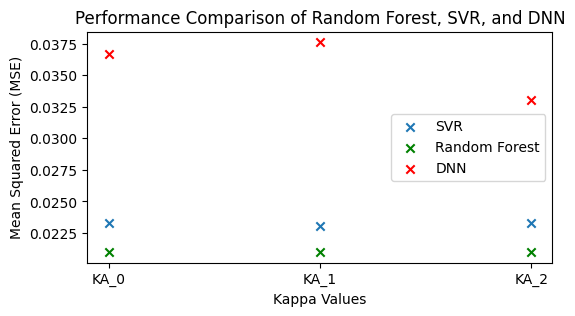

In [13]:
columns = ['FR_KA_0','FR_KA_1','FR_KA_2']
svr_mse_values = [fr_ka0_mse_array.mean(), fr_ka1_mse_array.mean(), fr_ka2_mse_array.mean()]
random_forest_mse_values = [fr_ka0_mse2_array.mean(), fr_ka1_mse2_array.mean(), fr_ka2_mse2_array.mean()]
dnn_mse_values = [fr_ka0_mse3_array.mean(), fr_ka1_mse3_array.mean(), fr_ka2_mse3_array.mean()]
plt.figure(figsize=(6,3))
plt.xticks([0,1,2],['KA_0', 'KA_1', 'KA_2'])
plt.scatter([0,1,2], svr_mse_values, marker='x', label='SVR')
plt.scatter([0,1,2], random_forest_mse_values, marker='x', label='Random Forest', color='green')
plt.scatter([0,1,2], dnn_mse_values, marker='x', label='DNN', color='red')
plt.ylabel("Mean Squared Error (MSE)")
plt.xlabel("Kappa Values")
plt.title("Performance Comparison of Random Forest, SVR, and DNN")
plt.legend()
plt.show()

Random forest performed better overall but especially when the kappa value was lower (less lenient with allowing deviation from frequented regions). However, the performance became generally the same when we consider a higher kappa value (more strict and not allowing deviation from frequented regions).

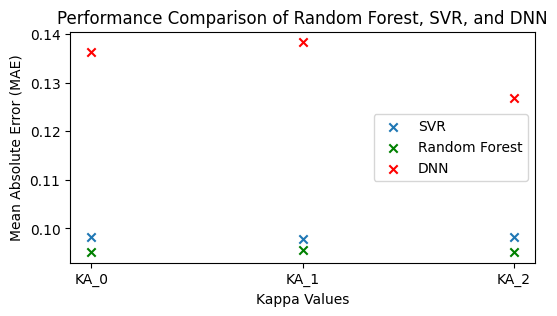

In [14]:
columns = ['FR_KA_0','FR_KA_1','FR_KA_2']
svr_mae_values = [fr_ka0_mae_array.mean(), fr_ka1_mae_array.mean(), fr_ka2_mae_array.mean()]
random_forest_mae_values = [fr_ka0_mae2_array.mean(), fr_ka1_mae2_array.mean(), fr_ka2_mae2_array.mean()]
dnn_mae_values = [fr_ka0_mae3_array.mean(), fr_ka1_mae3_array.mean(), fr_ka2_mae3_array.mean()]
plt.figure(figsize=(6,3))
plt.xticks([0,1,2],['KA_0', 'KA_1', 'KA_2'])
plt.scatter([0,1,2], svr_mae_values, marker='x', label='SVR')
plt.scatter([0,1,2], random_forest_mae_values, marker='x', label='Random Forest', color='green')
plt.scatter([0,1,2], dnn_mae_values, marker='x', label='DNN', color='red')
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Kappa Values")
plt.title("Performance Comparison of Random Forest, SVR, and DNN")
plt.legend()
plt.show()

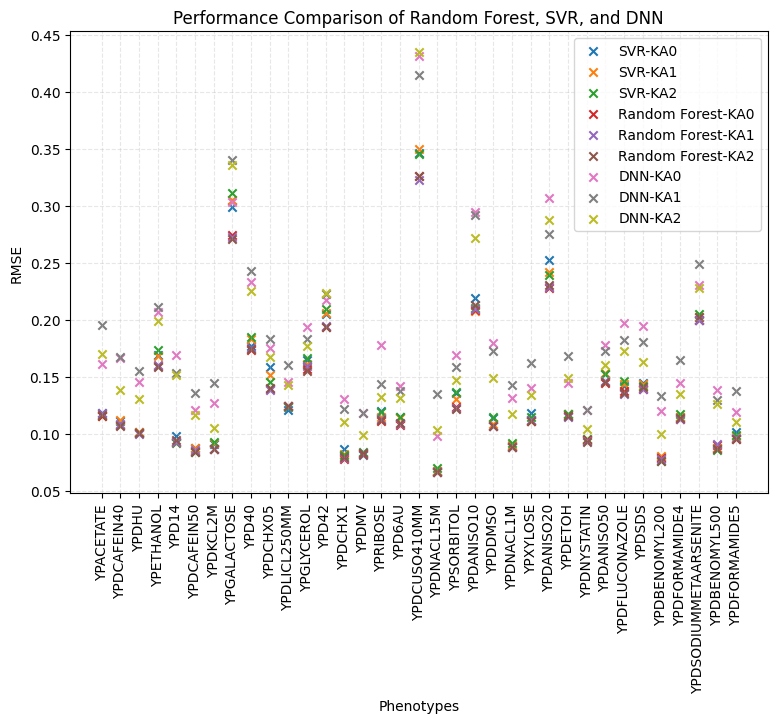

In [17]:
columns = phenotype_names
svr_mse_ka0 = np.sqrt(fr_ka0_mse_array)
svr_mse_ka1 = np.sqrt(fr_ka1_mse_array)
svr_mse_ka2 = np.sqrt(fr_ka2_mse_array)
random_forest_mse_ka0 = np.sqrt(fr_ka0_mse2_array)
random_forest_mse_ka1 = np.sqrt(fr_ka1_mse2_array)
random_forest_mse_ka2 = np.sqrt(fr_ka2_mse2_array)
dnn_mse_ka0 = np.sqrt(fr_ka0_mse3_array)
dnn_mse_ka1 = np.sqrt(fr_ka1_mse3_array)
dnn_mse_ka2 = np.sqrt(fr_ka2_mse3_array)
plt.figure(figsize=(9,6))
x = np.arange(len(phenotype_names))
plt.xticks(x, phenotype_names, rotation=90)
plt.scatter(x, svr_mse_ka0, marker='x', label='SVR-KA0')
plt.scatter(x, svr_mse_ka1, marker='x', label='SVR-KA1')
plt.scatter(x, svr_mse_ka2, marker='x', label='SVR-KA2')
plt.scatter(x, random_forest_mse_ka0, marker='x', label='Random Forest-KA0')
plt.scatter(x, random_forest_mse_ka1, marker='x', label='Random Forest-KA1')
plt.scatter(x, random_forest_mse_ka2, marker='x', label='Random Forest-KA2')
plt.scatter(x, dnn_mse_ka0, marker='x', label='DNN-KA0')
plt.scatter(x, dnn_mse_ka1, marker='x', label='DNN-KA1')
plt.scatter(x, dnn_mse_ka2, marker='x', label='DNN-KA2')
plt.ylabel("RMSE")
plt.xlabel("Phenotypes")
plt.title("Performance Comparison of Random Forest, SVR, and DNN")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

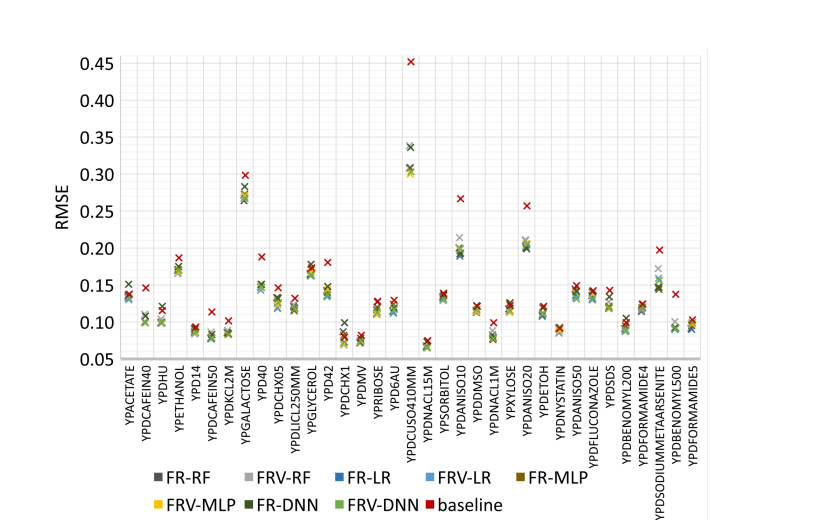

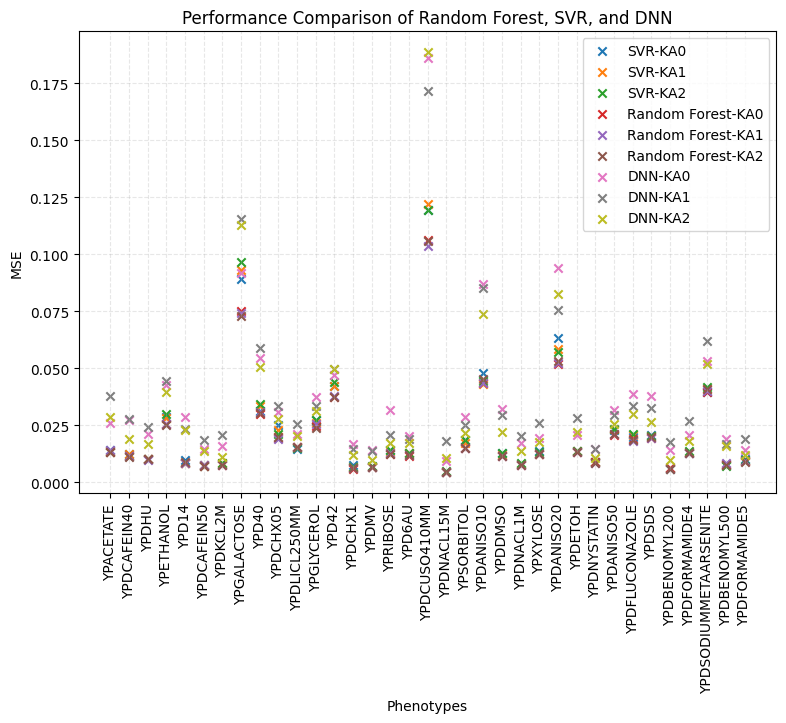

In [19]:
columns = phenotype_names
svr_mse_ka0 = fr_ka0_mse_array
svr_mse_ka1 =fr_ka1_mse_array
svr_mse_ka2 = fr_ka2_mse_array
random_forest_mse_ka0 = fr_ka0_mse2_array
random_forest_mse_ka1 = fr_ka1_mse2_array
random_forest_mse_ka2 = fr_ka2_mse2_array
dnn_mse_ka0 = fr_ka0_mse3_array
dnn_mse_ka1 = fr_ka1_mse3_array
dnn_mse_ka2 = fr_ka2_mse3_array
plt.figure(figsize=(9,6))
x = np.arange(len(phenotype_names))
plt.xticks(x, phenotype_names, rotation=90)
plt.scatter(x, svr_mse_ka0, marker='x', label='SVR-KA0')
plt.scatter(x, svr_mse_ka1, marker='x', label='SVR-KA1')
plt.scatter(x, svr_mse_ka2, marker='x', label='SVR-KA2')
plt.scatter(x, random_forest_mse_ka0, marker='x', label='Random Forest-KA0')
plt.scatter(x, random_forest_mse_ka1, marker='x', label='Random Forest-KA1')
plt.scatter(x, random_forest_mse_ka2, marker='x', label='Random Forest-KA2')
plt.scatter(x, dnn_mse_ka0, marker='x', label='DNN-KA0')
plt.scatter(x, dnn_mse_ka1, marker='x', label='DNN-KA1')
plt.scatter(x, dnn_mse_ka2, marker='x', label='DNN-KA2')
plt.ylabel("MSE")
plt.xlabel("Phenotypes")
plt.title("Performance Comparison of Random Forest, SVR, and DNN")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

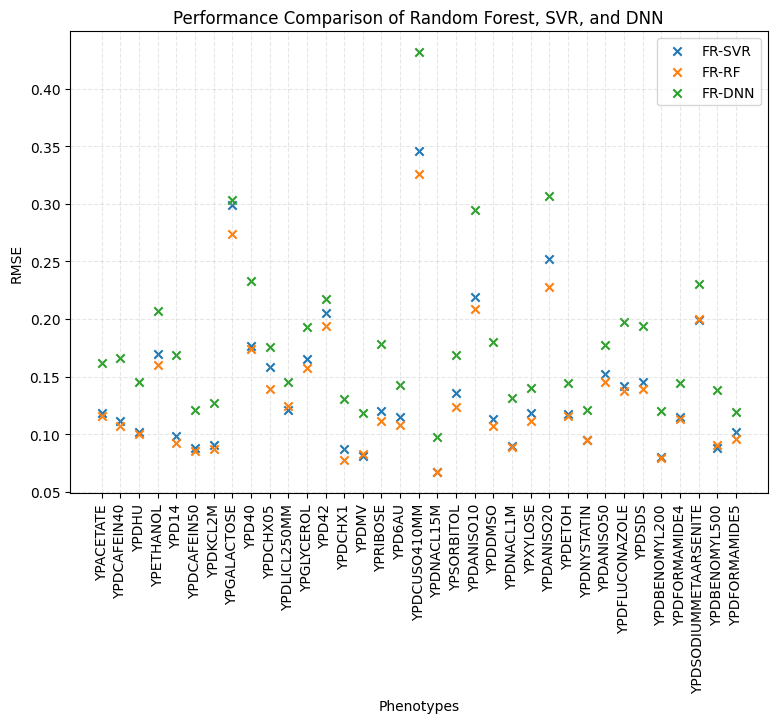

In [21]:
columns = phenotype_names
svr_mse_ka0 = np.sqrt(fr_ka0_mse_array)
svr_mse_ka1 = np.sqrt(fr_ka1_mse_array)
svr_mse_ka2 = np.sqrt(fr_ka2_mse_array)
svr_mse_avg = np.mean([svr_mse_ka0, svr_mse_ka1, svr_mse_ka2], axis=0)
random_forest_mse_ka0 = np.sqrt(fr_ka0_mse2_array)
random_forest_mse_ka1 = np.sqrt(fr_ka1_mse2_array)
random_forest_mse_ka2 = np.sqrt(fr_ka2_mse2_array)
random_forest_mse_avg = np.mean([random_forest_mse_ka0, random_forest_mse_ka1, random_forest_mse_ka2], axis=0)
dnn_mse_ka0 = np.sqrt(fr_ka0_mse3_array)
dnn_mse_ka1 = np.sqrt(fr_ka1_mse3_array)
dnn_mse_ka2 = np.sqrt(fr_ka2_mse3_array)
dnn_mse_avg = np.mean([dnn_mse_ka0, dnn_mse_ka1, dnn_mse_ka2], axis=0)
plt.figure(figsize=(9,6))
x = np.arange(len(phenotype_names))
plt.xticks(x, phenotype_names, rotation=90)
plt.scatter(x, svr_mse_ka0, marker='x', label='FR-SVR')
plt.scatter(x, random_forest_mse_ka0, marker='x', label='FR-RF')
plt.scatter(x, dnn_mse_ka0, marker='x', label='FR-DNN')
plt.ylabel("RMSE")
plt.xlabel("Phenotypes")
plt.title("Performance Comparison of Random Forest, SVR, and DNN")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

This last scatterplot is closer to the research paper's scatterplot where the